In [ ]:
!pip install MNE yasa

In [2]:
import mne
import yasa

In [3]:
import warnings
import logging
warnings.filterwarnings('ignore')

logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)
logging.getLogger("mne").setLevel(logging.WARNING)

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

In [4]:
%matplotlib qt

In [5]:
raw = mne.io.read_raw('007.vhdr', preload=True)

In [6]:
raw.info

<Info | 7 non-empty values
 bads: []
 ch_names: Fz, F3, F7, VEOG, C3, T7, Pz, P3, P7, O1, Oz, O2, P4, P8, Cz, ...
 chs: 24 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: 2021-11-23 15:45:12 UTC
 nchan: 24
 projs: []
 sfreq: 1000.0 Hz
>

In [7]:
raw.ch_names

['Fz',
 'F3',
 'F7',
 'VEOG',
 'C3',
 'T7',
 'Pz',
 'P3',
 'P7',
 'O1',
 'Oz',
 'O2',
 'P4',
 'P8',
 'Cz',
 'C4',
 'T8',
 'F4',
 'F8',
 'Zygom',
 'Corr',
 'Mark',
 'EDA',
 'Pulse']

In [ ]:
raw.plot()

# Поиск событий 

 Для поиска интервалов воспользуемся каналом Mark. Он должен принимать значения 1 и 0 в зависимости от отдыха или просмотра.
Изначально канал колеблется вниз - вверх в случайных интервалах, в дальнейшем создадим новый канал, который будет отвечать за события 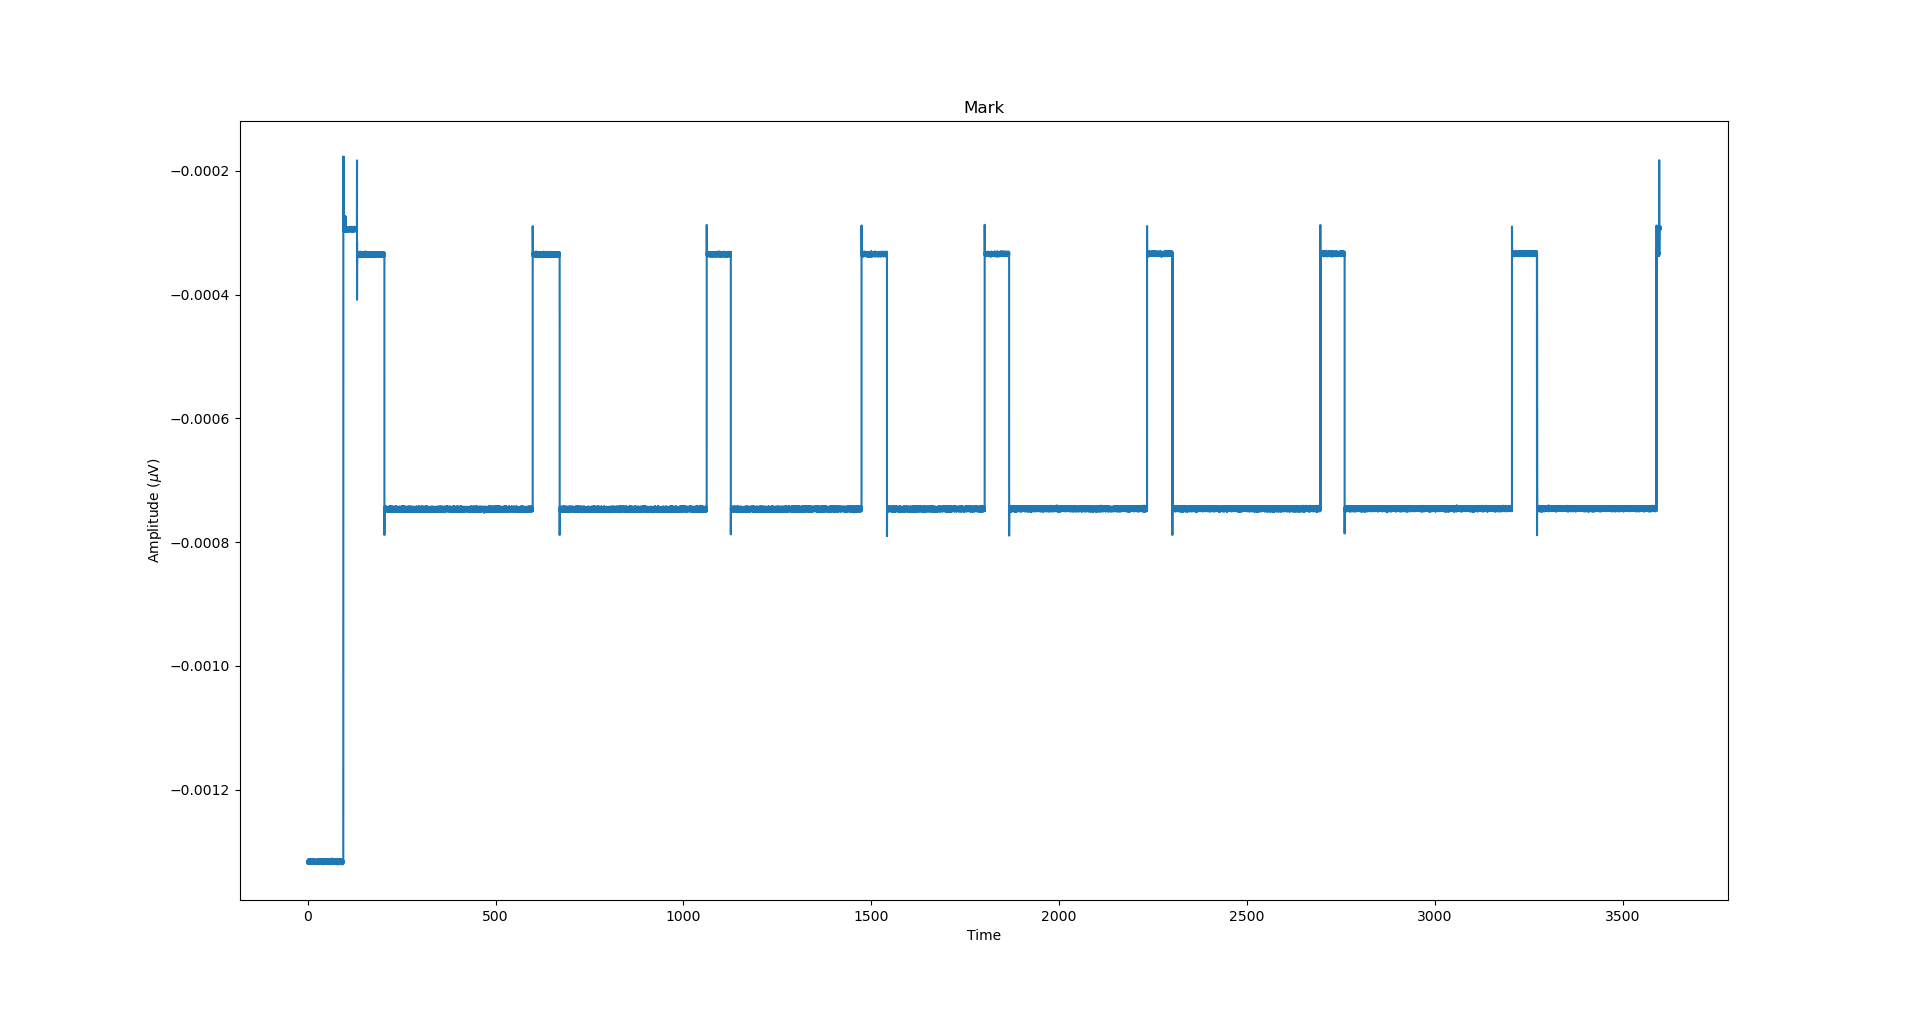

In [19]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(xlabel="Time", ylabel="Amplitude ($\mu$V)")
ax.set_title('Mark')
ax.plot(raw['Mark'][1], raw['Mark'][0][0]) 

In [21]:
def find_first_relax(stimulus):
    i = 0
    while i < len(stimulus[1]) and stimulus[0][0][i] < -0.0007:
        i += 1
    return i

In [22]:
def find_events(stimulus):
    events = []
    new_stim_ch = []
    i = 0
    j = find_first_relax(stimulus)
    first = True
    while i < len(stimulus[1]):
        if stimulus[0][0][i] < -0.0007 and i < j:
            new_stim_ch.append(1.0)
        elif stimulus[0][0][i] < -0.0007 and i > j:
            left = i
            while i < len(stimulus[1]) and stimulus[0][0][i] < -0.0007:
                new_stim_ch.append(1.0)
                i += 1
            right = i - 1
            events.append([stimulus[1][left] - 60, stimulus[1][left]])
            events.append([stimulus[1][left] + 0.001, stimulus[1][right]])
            j = right + 1
            new_stim_ch.append(2.0)
        else:
            new_stim_ch.append(2.0)
        i += 1
    return events, new_stim_ch

In [23]:
events = find_events(raw['Mark'])

In [24]:
for [start, end] in events[0]:
    print('Start', start, ' ', 'end', end)

Start 144.329   end 204.329
Start 204.33   end 598.989
Start 610.762   end 670.762
Start 670.7629999999999   end 1062.121
Start 1066.269   end 1126.269
Start 1126.27   end 1474.144
Start 1481.858   end 1541.858
Start 1541.859   end 1801.863
Start 1806.961   end 1866.961
Start 1866.962   end 2234.02
Start 2241.409   end 2301.409
Start 2301.4100000000003   end 2695.152
Start 2699.808   end 2759.808
Start 2759.809   end 3205.236
Start 3211.909   end 3271.909
Start 3271.9100000000003   end 3590.025


In [25]:
assert len(events[0]) == 16

In [26]:
len(events[0])

16

In [27]:
if len(events[1]) > len(raw['Mark'][1]):
    events[1].pop()

In [28]:
len(events[1])

3600150

In [29]:
len(raw['Mark'][1])

3600150

Создадим новый канал 'STI' в нем будут храниться значения списка events[1]
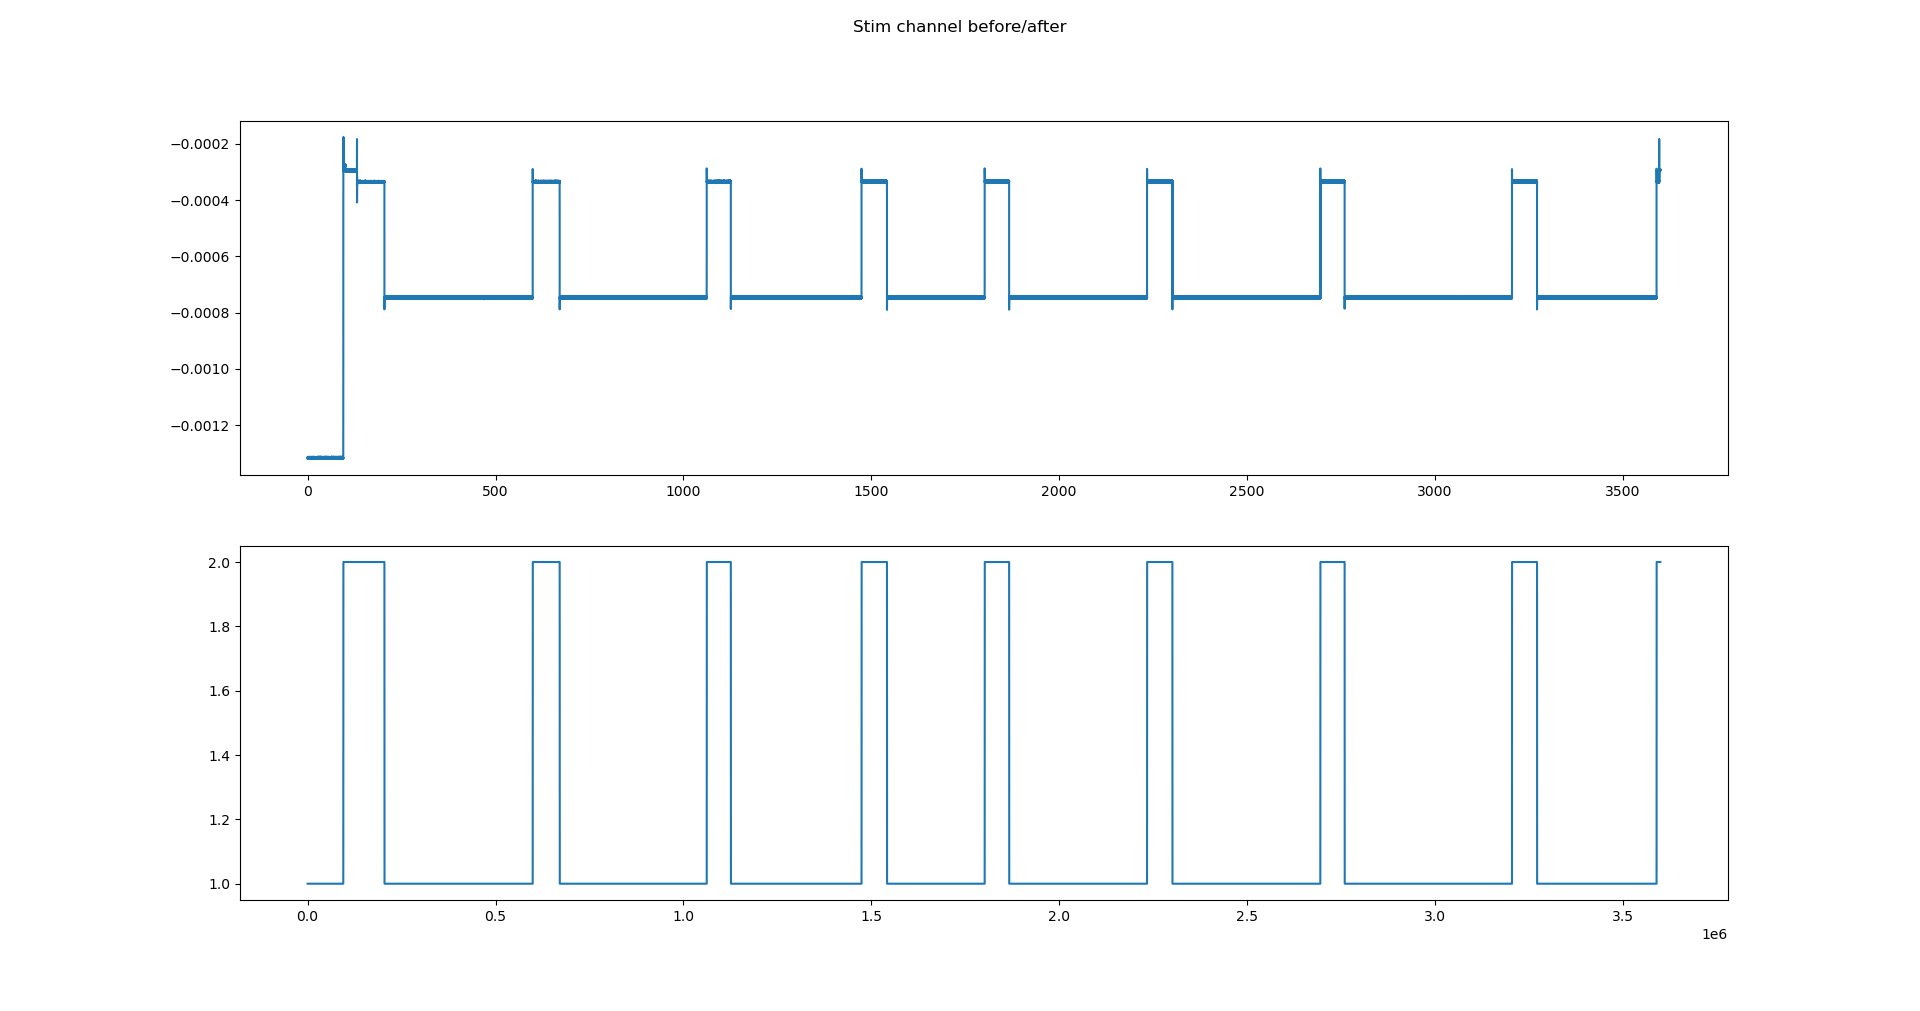

In [ ]:
fig, axs = plt.subplots(2)
fig.suptitle('Stim channel before/after')
axs[0].plot(raw['Mark'][1], raw['Mark'][0][0])
axs[1].plot(range(len(events[1])), events[1])

In [ ]:
info = mne.create_info(['STI'], raw.info['sfreq'], ['stim'])
stim_raw = mne.io.RawArray([events[1]], info)
raw.add_channels([stim_raw], force_update_info=True)

In [ ]:
raw.plot()

Теперь обновим аннотаци

In [32]:
import numpy as np

onset = np.array(events[0])[:, 0]
onset

array([ 144.329,  204.33 ,  610.762,  670.763, 1066.269, 1126.27 ,
       1481.858, 1541.859, 1806.961, 1866.962, 2241.409, 2301.41 ,
       2699.808, 2759.809, 3211.909, 3271.91 ])

In [43]:
first_film_order = [1, 4, 8, 5, 3, 7, 6, 2]
second_film_order = [2, 6, 7, 5, 3, 8, 4, 1]
film_order = []

In [34]:
duration = np.array(events[0])[:, 1] - np.array(events[0])[:, 0]
duration

array([ 60.   , 394.659,  60.   , 391.358,  60.   , 347.874,  60.   ,
       260.004,  60.   , 367.058,  60.   , 393.742,  60.   , 445.427,
        60.   , 318.115])

In [41]:
def make_description_v1(film_order):
    description = []
    for i in range(8):
        description.append('relax_before_' + str(film_order[i]))
        description.append('watch_' + str(film_order[i]))
    return description

In [36]:
def make_description_v2(annot):
    description = []
    for i in range(0, 16, 2):
        description.append('relax_before_' + annot[i]['description'].split('/')[0])
        description.append('watch_' + str(int(annot[i + 1]['description'].split('/')[1]) - 8))
    return description

In [44]:
description = make_description_v1(first_film_order )
description

['relax_before_1',
 'watch_1',
 'relax_before_4',
 'watch_4',
 'relax_before_8',
 'watch_8',
 'relax_before_5',
 'watch_5',
 'relax_before_3',
 'watch_3',
 'relax_before_7',
 'watch_7',
 'relax_before_6',
 'watch_6',
 'relax_before_2',
 'watch_2']

In [45]:
my_annot = mne.Annotations(onset=onset,  # in seconds
                           duration=duration,  # in seconds, too
                           description=description)

In [46]:
print(my_annot)

<Annotations | 16 segments: relax_before_1 (1), relax_before_2 (1), ...>


In [ ]:
raw.set_annotations(my_annot)

In [ ]:
raw.plot()

# Обработка записи 

In [ ]:
raw.drop_channels(['Zygom', 'Corr', 'Mark', 'EDA'])

In [ ]:
raw.set_channel_types(mapping={'Fz' : 'eeg', 'F3' : 'eeg', 'F7' : 'eeg', 'VEOG': 'eog',
                  'C3' : 'eeg', 'T7' : 'eeg', 'Pz' : 'eeg', 'P3' : 'eeg',
                  'P7' : 'eeg', 'O1' : 'eeg', 'Oz' : 'eeg', 'O2' : 'eeg',
                  'P4' : 'eeg', 'P8' : 'eeg', 'Cz' : 'eeg',
                      'C4' : 'eeg', 'T8' : 'eeg', 'F4' : 'eeg', 'F8' : 'eeg', 'Pulse': 'ecg', 'Zygom' : 'bio', 'Corr' : 'bio', 'Mark' : 'bio', 'EDA' : 'bio',  'STI' : 'stim' })




In [ ]:
raw.set_montage('standard_1020')

Отфильтровка

In [51]:
current_sfreq = raw.info['sfreq']
desired_sfreq = 128  # Hz
decim = np.round(current_sfreq / desired_sfreq).astype(int)
obtained_sfreq = current_sfreq / decim
lowpass_freq = obtained_sfreq / 3.
print(current_sfreq, desired_sfreq, decim, obtained_sfreq , lowpass_freq )

1000.0 128 8 125.0 41.666666666666664


In [52]:
raw_filtered = raw.copy().resample(128.).filter(l_freq=0.05, h_freq=lowpass_freq)
raw_filtered.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fz, F3, F7, VEOG, C3, T7, Pz, P3, P7, O1, Oz, O2, P4, P8, Cz, ...
 chs: 18 EEG, 1 EOG, 4 BIO, 1 ECG, 1 STIM
 custom_ref_applied: False
 dig: 21 items (3 Cardinal, 18 EEG)
 highpass: 0.1 Hz
 lowpass: 41.7 Hz
 meas_date: 2021-11-23 15:45:12 UTC
 nchan: 25
 projs: []
 sfreq: 128.0 Hz
>

In [ ]:
raw_filtered.plot()

# Поиск артефактов с помощью канала EOG (ICA)

In [ ]:
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs,
                               corrmap)

In [ ]:
ica = ICA(n_components=15, max_iter='auto', random_state=97)
ica.fit(raw_filtered)

In [ ]:
ica.plot_components()

In [ ]:
ica.exclude = []
# find which ICs match the EOG pattern
eog_indices, eog_scores = ica.find_bads_eog(raw_filtered, ch_name='VEOG')
ica.exclude = eog_indices

In [ ]:
eog_indices

In [ ]:
ica.plot_scores(eog_scores)

In [ ]:
ica.plot_properties(raw_filtered, picks=eog_indices)

In [ ]:
ica.plot_sources(raw_filtered)

# Поиск артефактов с помощью канала Pulse (ICA)

In [ ]:
ica.exclude = []
# find which ICs match the ECG pattern
ecg_indices, ecg_scores = ica.find_bads_ecg(raw_filtered, method='correlation',
                                            threshold='auto', ch_name='Pulse')

In [ ]:
ecg_indices

In [ ]:
ica.plot_scores(ecg_scores)

In [ ]:
#ica.plot_properties(raw, picks=ecg_indices)

In [ ]:
ica.exclude = ecg_indices + eog_indices
ica.apply(raw_filtered)

# Сохранение отфильтрованной и очищенной записи

In .fif format

In [ ]:
raw_filtered.save('Subject_filtered_raw.fif')

In BrainVision format

In [ ]:
import numpy as np

In [ ]:
list_of_events = np.zeros(48)
list_of_events

In [ ]:
list_of_events = list_of_events.reshape(16, 3)

In [ ]:
types_of_events = make_description(film_order)
for i in range(len(types_of_events)):
    types_of_events[i] = int(types_of_events[i].split('_')[-1]) if i % 2 == 0 else int(types_of_events[i].split('_')[-1]) + 10
types_of_events

In [ ]:
list_of_events[:, 0] = np.array(events[0])[:, 0] * 1e3
list_of_events[:, 1] = types_of_events
list_of_events[:, 2] = (np.array(events[0])[:, 1] - np.array(events[0])[:, 0]) * 1e3
list_of_events = list_of_events.astype(int)
list_of_events

In [ ]:
import pybv

In [ ]:
pybv.write_brainvision(data=raw.get_data(), sfreq=raw.info['sfreq'], ch_names=['Fz', 'F3', 'F7','VEOG',
                      'C3', 'T7', 'Pz', 'P3',
                      'P7', 'O1', 'Oz', 'O2',
                      'P4', 'P8', 'Cz',
                      'C4', 'T8', 'F4', 'F8', 'Pulse', 'STI'],
                     folder_out='./',
                     events=list_of_events,
                     fname_base='Subjectfiltered_raw',
                     unit=['µV' for i in range(21)])

# Проверим сохраненные данные

In [ ]:
brainvision = mne.io.read_raw_brainvision('Subject_filtered_raw.vhdr', preload=True)

In [ ]:
fif = mne.io.read_raw('Subject_filtered_raw.fif')

In [ ]:
brainvision.info

In [ ]:
fif.info

In [ ]:
#filter 0.05, 30 because pybv doesn't save pass
brainvision.filter(0.05, 30)

In [ ]:
brainvision.plot()

In [ ]:
fif.plot()

# Обрезка отфильтрованных данных

In [ ]:
from tqdm import tqdm_notebook

Insert Subject in format 0xx.

In [ ]:
Subject = input()

In [ ]:
raw = mne.io.read_raw('filtered_full/' + Subject + 'filtered_raw.fif')

In [ ]:
for i in range(16):
    print(i + 1, 'event - ', 'description: ', raw.annotations[i]['description'], ' ','start: ', raw.annotations[i]['onset'], 's ', 'end: ', raw.annotations[i]['onset'] + raw.annotations[i]['duration'] , 's')

In [ ]:
for i in tqdm_notebook(range(16)):
    cpy = raw.copy()
    annot = cpy.annotations[i]
    cpy.crop(tmin=annot['onset'], tmax=(annot['onset'] + annot['duration']))
    if not os.path.exists('Cuts_filtered/' + str(int(Subject))):
        os.makedirs('Cuts_filtered/' + str(int(Subject)))
    cpy.save('Cuts_filtered/' + str(int(Subject)) +'/' + Subject + '_filtered_' + anot['description'] + '_.fif')

# Проверим первый отдых и первый просмотр

In [ ]:
relax_first = mne.io.read_raw(Subject + '_filtered_relax_before_1_.fif')

In [ ]:
watch_first = mne.io.read_raw(Subject + '_filtered_watch_1_.fif')

In [ ]:
relax_first.plot()

In [ ]:
watch_first.plot()

# Фурье - анализ

# Алгоритм, обрабатывающий все отдыхи и просмотры

In [ ]:
import warnings
import logging
import pandas as pd
warnings.filterwarnings('ignore')

logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)
logging.getLogger("mne").setLevel(logging.WARNING)

In [ ]:
import yasa
import os
from scipy.signal import welch

In [ ]:
sf = 1000
win = int(4 * sf)
chans = ['Fz', 'F3', 'F7','C3', 'T7', 'Pz', 'P3','P7', 'O1', 'Oz', 'O2','P4', 'P8', 'Cz','C4', 'T8', 'F4', 'F8']

In [ ]:
relax_first.drop_channels(['VEOG', 'Pulse', 'STI'])
watch_first.drop_channels(['VEOG', 'Pulse', 'STI'])

In [ ]:
freqs_relax, psd_relax = welch(relax_first.get_data()  * 1e6, sf, nperseg=win, average='median')
freqs_watch, psd_watch = welch(watch_first.get_data()  * 1e6, sf, nperseg=win, average='median')
bp_relax = yasa.bandpower_from_psd(psd_relax, freqs_relax,chans, bands=
                                   [(k, k + 1, str(k)) for k in range(30)], relative=False).drop(columns=['FreqRes', 'Relative'])
bp_watch = yasa.bandpower_from_psd(psd_watch, freqs_watch,chans, bands=
                                   [(k, k + 1, str(k)) for k in range(30)], relative=False).drop(columns=['FreqRes', 'Relative'])

In [ ]:
bp_relax

In [ ]:
bp_watch

In [ ]:
bp_watch = bp_watch.drop(columns=['TotalAbsPow'])

In [ ]:
bp_relax = bp_relax.drop(columns=['TotalAbsPow'])

In [ ]:
X = list(range(1, 31))
fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(bottom=0.2, right=3.8, top=1.9)
ax.set_title('Film1')
for i in tqdm_notebook(range(18)):
    ax.plot(X, np.array(bp_watch.iloc[i])[1:] / np.array(bp_relax.iloc[i])[1:], label=chans[i])
ax.legend()
fig.savefig('test.png', bbox_inches='tight')

In [ ]:
X = list(range(0, 31))
for i in tqdm_notebook(range(7)):
    frames = []
    frames_rel = []
    for k in tqdm_notebook(range(8)):
        film = str(k + 1)
        Subject = ''
        if len(str(i + 1)) == 1:
            Subject = '00' + str(i + 1)
        elif len(str(i + 1)) == 2:
            Subject = '0' + str(i + 1)
        relax = mne.io.read_raw('Cuts_filtered/' + str(int(i + 1))  +  '/' + Subject + '_filtered_relax_before_' + film + '_.fif')
        watch = mne.io.read_raw('Cuts_filtered/' + str(int(i + 1))  + '/' + Subject + '_filtered_watch_' + film + '_.fif')
        relax.drop_channels(['Pulse', 'STI'])
        watch.drop_channels(['Pulse', 'STI'])
        if 'VEOG' in relax.ch_names:
            relax.drop_channels(['VEOG'])
            watch.drop_channels(['VEOG'])

        freqs_relax, psd_relax = welch(relax.get_data()  * 1e6, sf, nperseg=win, average='median')
        freqs_watch, psd_watch = welch(watch.get_data()  * 1e6, sf, nperseg=win, average='median')
        
        bp_relax = yasa.bandpower_from_psd(psd_relax, freqs_relax,chans, bands=
                                   [(4, 8, 'Theta'), (8, 12, 'Alpha'), (12, 30, 'Beta')], relative=False).drop(columns=['FreqRes', 'Relative', 'TotalAbsPow'])
        bp_watch = yasa.bandpower_from_psd(psd_watch, freqs_watch,chans, bands=
                                   [(4, 8, 'Theta'), (8, 12, 'Alpha'), (12, 30, 'Beta')], relative=False).drop(columns=['FreqRes', 'Relative', 'TotalAbsPow'])
        p_relax = yasa.bandpower(relax,relax.info['sfreq'], bands=
                                   [(4, 8, 'Theta_ratio'), (8, 12, 'Alpha_ratio'), (12, 30, 'Beta_ratio')], relative=True).drop(columns=['FreqRes', 'Relative'])
        p_watch = yasa.bandpower(watch, watch.info['sfreq'], bands=
                                   [(4, 8, 'Theta_ratio'), (8, 12, 'Alpha_ratio'), (12, 30, 'Beta_ratio')], relative=True).drop(columns=['FreqRes', 'Relative'])
        fig = plt.figure()
        ax = fig.add_subplot()
        fig.subplots_adjust(bottom=0.2, right=3.8, top=1.9)
        ax.set_title('Film' + film)
        for j in tqdm_notebook(range(18)):
            df_relax = pd.DataFrame(bp_relax.loc[j]).transpose()
            df_watch = pd.DataFrame(bp_watch.loc[j]).transpose()
            dr = pd.DataFrame(p_relax.loc[relax.ch_names[j]]).transpose()
            dr.rename(index={relax.ch_names[j]:j}, inplace=True)
            df_relax = df_relax.join(dr)
            dw = pd.DataFrame(p_watch.loc[watch.ch_names[j]]).transpose()
            dw.rename(index={relax.ch_names[j]:j}, inplace=True)
            df_watch = df_watch.join(dw)
            df_relax.rename(index={j:'F' + film + '_relax'}, inplace=True)
            df_watch.rename(index={j:'F' + film + '_watch'}, inplace=True)

            df_rel = {
                'Theta_watch-relax' : float(df_watch['Theta']) - float(df_relax['Theta']),
                'Alpha_watch-relax' : float(df_watch['Alpha']) - float(df_relax['Alpha']),
                'Beta_watch-relax' : float(df_watch['Beta']) - float(df_relax['Beta']),
            }
            df_rel = pd.DataFrame(df_rel, index=['F' + film + '_' + watch.ch_names[j]])
            df_div = {
                'Beta/Alpha' : float(df_rel['Beta_watch-relax']) / float(df_rel['Alpha_watch-relax']),
                'Beta/(Alpha + Theta)' : float(df_rel['Beta_watch-relax']) / (float(df_rel['Alpha_watch-relax'] + float(df_rel['Theta_watch-relax']))),
            }
            df_div = pd.DataFrame(df_div, index=['F' + film + '_' + watch.ch_names[j]])
            df_all = df_rel.join(df_div)
            frames_rel.append(df_all)
            frames.append(df_relax)
            frames.append(df_watch)
            ax.plot(X, np.array(bp_watch.iloc[j])[1:] / np.array(bp_relax.iloc[j])[1:], label=chans[j])
            ax.legend()
        if not os.path.exists('BandPower/Images/S' + str(i + 1) + '/'):
              os.makedirs('BandPower/Images/S' + str(i + 1) + '/')
        fig.savefig('BandPower/Images/S' + str(i + 1) + '/' + 'F' + film + '.png', bbox_inches='tight')
    result_rel = pd.concat(frames_rel)
    result_rel.to_excel('BandPower/Excel/S' + str(i + 1) + '_ratio.xlsx')
    result = pd.concat(frames)
    result.to_excel('BandPower/Excel/S' + str(i + 1) + '.xlsx')

# Построение спектрограмм

 3 Метода : через scipy и кастомный, а также с помощью mne.Epochs (все отрезки должны быть одинаковой длины - можно взять по 550с)

In [ ]:
from scipy import signal

In [ ]:
relax_first = mne.io.read_raw('Cuts/6/006_filtered_relax_before_1_.fif')

In [ ]:
watch_first = mne.io.read_raw('Cuts/6/006_filtered_watch_1_.fif')

In [ ]:
f, t, Sxx = signal.spectrogram(relax_first['Fz'][0][0], 1000)
plt.pcolormesh(t, f[0:9], Sxx[0:9], shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [ ]:
f, t, Sxx = signal.spectrogram(watch_first['Fz'][0][0], 1000)
plt.pcolormesh(t, f[0:9], Sxx[0:9], shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(bottom=0.2, right=3.8, top=1.9)
#ax.plot(X[0:-1:100], Z[3][0:-1:100], label=str(int(Y[2])) + '-' + str(int(Y[3])))
ax.plot(t, Sxx[0], label='Theta')
ax.plot(t, Sxx[1], label='Alpha')
ax.plot(t, (Sxx[2] + Sxx[3] + Sxx[4] + Sxx[5] + Sxx[6]) / 5, label='Beta')
#ax.plot(X[0:-1:100], Z[5][0:-1:100], label=str(int(Y[4])) + '-' + str(int(Y[5])))
#ax.plot(X[0:-1:100], Z[6][0:-1:100], label=str(int(Y[5])) + '-' + str(int(Y[6])))
ax.set_title('Subject 1, Film 1, watch')
ax.set_ylabel('Amplitude ($\mu$V)')
ax.set_xlabel('Time [sec]')
ax.legend()
fig.savefig('power_spectrogramm.png', bbox_inches='tight' )

И кастомный способ: https://github.com/JoseGuzman/myIPythonNotebooks

In [ ]:
import math

In [ ]:
eeg = watch_first['Fz'][0][0] * 1e6 # amplitude in microVolts
sr = int(raw.info['sfreq']) # sampling rate in sec
time = np.arange(eeg.size) / sr

FourierCoeff = np.fft.fft(eeg) / eeg.size
DC = [np.abs(FourierCoeff[0])]
amp = np.concatenate((DC, 2 * np.abs(FourierCoeff[1:])))  

# compute frequencies vector until half the sampling rate
Nyquist = sr / 2

Nsamples = int( math.floor(eeg.size / 2) )
hz = np.linspace(0, Nyquist, num = Nsamples + 1 )
dhz = hz[1]

WinLength = int(0.25 * sr) # 500 points (0.25 sec, 250 ms)
step = int(0.025 * sr) # 25 points (or 25 ms)

# we have less resolution here because the signals are smaller
Nsamples = int(np.floor(WinLength / 2) )
hz = np.linspace(0, Nyquist, Nsamples + 1)
dfreq = hz[1]
nsteps = int(np.floor ( (eeg.size - WinLength ) / step) )
myamp = list()
for i in range(nsteps):
    data = eeg[i*step:i*step+WinLength]
    FourierCoeff = np.fft.fft(data)/WinLength
    DC = [np.abs(FourierCoeff[0])] # DC component
    amp = np.concatenate((DC, 2 * np.abs(FourierCoeff[1:])))
    amp = amp[:int(45/dfreq)]
    myamp.append( amp )

power = np.power(myamp, 2)
#logpower = 10*np.log10(power)
fig, ax = plt.subplots(2,1, figsize = (16,8), constrained_layout=True)
#fig.suptitle('Time-frequency power via short-time FFT')

ax[0].plot(time, eeg, lw = 1, color='C0')
ax[0].set_ylabel('Amplitude ($\mu V$)')
ax[0].set_title('EEG signal')

# spectrum is a ContourSet object
dt = eeg.size/ sr / nsteps # 120 seconds in number of steps
X = np.arange(nsteps)*dt
Y = hz[:int(45/dfreq)]
Z = np.array(myamp).T
levels = 45
spectrum = ax[1].contourf(X,Y,Z,levels, cmap='jet')#,'linecolor','none')

# get the colormap
cbar = plt.colorbar(spectrum)#, boundaries=np.linspace(0,1,5))
cbar.ax.set_ylabel('Amplitude ($\mu$V)', rotation=90)
cbar.set_ticks(np.arange(0,50,10))

#A working example (for any value range) with five ticks along the bar is:

m0=int(np.floor(np.min(myamp)))            # colorbar min value
m4=int(np.ceil(np.max(myamp)))             # colorbar max value
m1=int(1*(m4-m0)/4.0 + m0)               # colorbar mid value 1
m2=int(2*(m4-m0)/4.0 + m0)               # colorbar mid value 2
m3=int(3*(m4-m0)/4.0 + m0)               # colorbar mid value 3
cbar.set_ticks([m0,m1,m2,m3,m4])
cbar.set_ticklabels([m0,m1,m2,m3,m4])
#cbar.set_ticks(np.arange(0, 1.1, 0.5))

ax[1].axhline(y = 8, linestyle='--', linewidth = 1.5, color='white')
ax[1].axhline(y = 12, linestyle='--', linewidth = 1.5, color='white')
ax[1].set_ylim([0, 40])
ax[1].set_yticks(range(0, 40, 5))
ax[1].set_ylabel('Frequency (Hz)')


for myax in ax:
    myax.set_xlim(0, eeg.size / sr)
    myax.set_xticks(np.arange(0, eeg.size/sr, 30))
    myax.set_xlabel('Time (sec.)')

# Все вместе

In [ ]:
def get_spectral(raw, ch, is_relax, path):
    eeg = raw[ch][0][0] * 1e6 # amplitude in microVolts
    sr = int(raw.info['sfreq']) # sampling rate in sec
    time = np.arange(eeg.size) / sr
    
    FourierCoeff = np.fft.fft(eeg) / eeg.size
    DC = [np.abs(FourierCoeff[0])]
    amp = np.concatenate((DC, 2 * np.abs(FourierCoeff[1:])))  

    # compute frequencies vector until half the sampling rate
    Nyquist = sr / 2
    
    Nsamples = int( math.floor(eeg.size / 2) )
    hz = np.linspace(0, Nyquist, num = Nsamples + 1 )
    dhz = hz[1]
    
    WinLength = int(0.25 * sr) # 500 points (0.25 sec, 250 ms)
    step = int(0.025 * sr) # 25 points (or 25 ms)

    if not os.path.isfile(path + ('relax_spectrogram_custom_data.csv' if is_relax else 'watch_spectrogram_custom_data.csv')) or not os.path.isfile(path + ('relax_spectrogram_custom.jpg' if is_relax else 'watch_spectrogram_custom.jpg')):
        # we have less resolution here because the signals are smaller
        Nsamples = int(np.floor(WinLength / 2) )
        hz = np.linspace(0, Nyquist, Nsamples + 1)
        dfreq = hz[1]
        nsteps = int(np.floor ( (eeg.size - WinLength ) / step) )
        myamp = list()
        for i in range(nsteps):
            data = eeg[i*step:i*step+WinLength]
            FourierCoeff = np.fft.fft(data)/WinLength
            DC = [np.abs(FourierCoeff[0])] # DC component
            amp = np.concatenate((DC, 2 * np.abs(FourierCoeff[1:])))
            amp = amp[:int(45/dfreq)]
            myamp.append( amp )

        power = np.power(myamp, 2)
        #logpower = 10*np.log10(power)
        fig, ax = plt.subplots(2,1, figsize = (16,8), constrained_layout=True)
        #fig.suptitle('Time-frequency power via short-time FFT')
    
        ax[0].plot(time, eeg, lw = 1, color='C0')
        ax[0].set_ylabel('Amplitude ($\mu V$)')
        ax[0].set_title('EEG signal')

        # spectrum is a ContourSet object
        dt = eeg.size/ sr / nsteps # 120 seconds in number of steps
        X = np.arange(nsteps)*dt
        Y = hz[:int(45/dfreq)]
        Z = np.array(myamp).T
        levels = 45
        spectrum = ax[1].contourf(X,Y,Z,levels, cmap='jet')#,'linecolor','none')

        # get the colormap
        cbar = plt.colorbar(spectrum)#, boundaries=np.linspace(0,1,5))
        cbar.ax.set_ylabel('Amplitude ($\mu$V)', rotation=90)
        cbar.set_ticks(np.arange(0,50,10))

        #A working example (for any value range) with five ticks along the bar is:

        m0=int(np.floor(np.min(myamp)))            # colorbar min value
        m4=int(np.ceil(np.max(myamp)))             # colorbar max value
        m1=int(1*(m4-m0)/4.0 + m0)               # colorbar mid value 1
        m2=int(2*(m4-m0)/4.0 + m0)               # colorbar mid value 2
        m3=int(3*(m4-m0)/4.0 + m0)               # colorbar mid value 3
        cbar.set_ticks([m0,m1,m2,m3,m4])
        cbar.set_ticklabels([m0,m1,m2,m3,m4])
        #cbar.set_ticks(np.arange(0, 1.1, 0.5))

        ax[1].axhline(y = 8, linestyle='--', linewidth = 1.5, color='white')
        ax[1].axhline(y = 12, linestyle='--', linewidth = 1.5, color='white')
        ax[1].set_ylim([0, 40])
        ax[1].set_yticks(range(0, 40, 5))
        ax[1].set_ylabel('Frequency (Hz)')


        for myax in ax:
            myax.set_xlim(0, eeg.size / sr)
            myax.set_xticks(np.arange(0, eeg.size/sr, 30))
            myax.set_xlabel('Time (sec.)')
        
        df = pd.DataFrame(Z)
        df.loc[11] = pd.DataFrame(X).transpose().loc[0]
        df.rename(index={11:'time'}, inplace=True)
    
    if not os.path.isfile(path + ('relax_spectrogram_custom_data.csv' if is_relax else 'watch_spectrogram_custom_data.csv')):
        df.to_csv(path + ('relax_spectrogram_custom_data.csv' if is_relax else 'watch_spectrogram_custom_data.csv'))
    if not os.path.isfile(path + ('relax_spectrogram_custom.jpg' if is_relax else 'watch_spectrogram_custom.jpg')):
        fig.savefig(path + ('relax_spectrogram_custom.jpg' if is_relax else 'watch_spectrogram_custom.jpg'), bbox_inches='tight')
        plt.clf()
        for myax in ax:
            myax.cla()
        
        plt.close(fig)
    
    if not os.path.isfile(path + ('relax_time_amplitude_scipy.jpg' if is_relax else 'watch_time_amplitude_scipy.jpg')) or not os.path.isfile(path + ('relax_spectrogram_scipy_data.csv' if is_relax else 'watch_spectrogram_scipy_data.csv')) or not os.path.isfile(path + ('relax_spectrogram_scipy.jpg' if is_relax else 'watch_spectrogram_scipy.jpg')):
        myparams = dict(nperseg = WinLength, noverlap = WinLength-step, return_onesided=True, mode='magnitude')
        f, t, Sxx = signal.spectrogram(x = eeg, fs = sr, **myparams)
    
        fig = plt.figure()
        ax = fig.add_subplot()
        fig.subplots_adjust(bottom=0.2, right=3.8, top=1.9)
        #ax.plot(X[0:-1:100], Z[3][0:-1:100], label=str(int(Y[2])) + '-' + str(int(Y[3])))
        ax.plot(t, Sxx[0], label='Theta')
        ax.plot(t, Sxx[1], label='Alpha')
        ax.plot(t, (Sxx[2] + Sxx[3] + Sxx[4] + Sxx[5] + Sxx[6]) / 5, label='Beta')
        ax.legend()
        #ax.plot(X[0:-1:100], Z[5][0:-1:100], label=str(int(Y[4])) + '-' + str(int(Y[5])))
        #ax.plot(X[0:-1:100], Z[6][0:-1:100], label=str(int(Y[5])) + '-' + str(int(Y[6])))
        #ax.set_title(path.split('/')[2] + ' ' + path.split('/')[3] + ' ' + path.split('/')[4] + ' ' + 'relax' if is_relax else 'watch')
        ax.set_ylabel('Amplitude ($\mu$V)')
        ax.set_xlabel('Time [sec]')
    
    if not os.path.isfile(path + ('relax_time_amplitude_scipy.jpg' if is_relax else 'watch_time_amplitude_scipy.jpg')):
        fig.savefig(path + ('relax_time_amplitude_scipy.jpg' if is_relax else 'watch_time_amplitude_scipy.jpg'), bbox_inches='tight')
        plt.clf()
        ax.cla()
        plt.close(fig)
        
    if not os.path.isfile(path + ('relax_spectrogram_scipy_data.csv' if is_relax else 'watch_spectrogram_scipy_data.csv')) or not os.path.isfile(path + ('relax_spectrogram_scipy.jpg' if is_relax else 'watch_spectrogram_scipy.jpg')):
        fig = plt.figure()
        ax = fig.add_subplot()
        ax.pcolormesh(t, f[0:9], Sxx[0:9], shading='gouraud')
        ax.set_ylabel('Frequency [Hz]')
        ax.set_xlabel('Time [sec]')
    
        df = pd.DataFrame(Sxx[0:9])
        df.loc[9] = pd.DataFrame(t).transpose().loc[0]
        df.rename(index={9:'time'}, inplace=True)
    
    if not os.path.isfile(path + ('relax_spectrogram_scipy_data.csv' if is_relax else 'watch_spectrogram_scipy_data.csv')):
        df.to_csv(path + ('relax_spectrogram_scipy_data.csv' if is_relax else 'watch_spectrogram_scipy_data.csv'))
    if not os.path.isfile(path + ('relax_spectrogram_scipy.jpg' if is_relax else 'watch_spectrogram_scipy.jpg')):
        fig.savefig(path + ('relax_spectrogram_scipy.jpg' if is_relax else 'watch_spectrogram_scipy.jpg'))
        plt.close(fig)

MNE :

In [ ]:
for i in tqdm(range(1, n_subj + 1):
    Subject = str(i)
    for j in tqdm(range(1, 9)):
        film = str(j)
        raw = mne.io.read_raw('filtered_full/00' + Subject + 'filtered_raw.fif')
        events = mne.events_from_annotations(raw)
        epochs = mne.Epochs(raw, tmin=0., tmax=550, events=events[0],baseline=(0, 0), event_id= events[1])
        for id in events[1]:
            if id.split('_')[0] == 'relax':
                continue
            try:
                fig = epochs[id].plot_psd(fmin=0., fmax=30.)
                fig.set_size_inches(20, 10.5) 
                fig.savefig('BandPower/Images/S' + str(i) + '/F' + str(j) + '_channels_psd_mne.png', bbos_inches='tight')
            except Exception as e:
                pass
            if not os.path.isfile('BandPower/Images/S' + str(i) + '/F' + str(j) + 'psd_mne.png'):
                try:
                    fig = epochs[id].plot_psd(fmin=0., fmax=30., average=True, spatial_colors=False)
                  fig.set_size_inches(20, 10.5) 
                  fig.savefig('BandPower/Images/S' + str(i) + '/F' + str(j) + 'psd_mne.png', bbos_inches='tight')
                except Exception as e:
                      pass
            if not os.path.isfile('BandPower/Images/S' + str(i) + '/F' + str(j) + 'psd_topomap_mne.png'):
                fig = epochs.plot_psd_topomap(normalize=False)
                fig.set_size_inches(20, 10.5) 
                fig.savefig('BandPower/Images/S' + str(i) + '/F' + str(j) + 'psd_topomap_mne.png', bbos_inches='tight')
            file_paths = ([not os.path.isfile('Spectrograms/S' + str(i) + '/F' + str(j) + '/' + raw.ch_names[k] + '/' + id.split('_')[0] + '_mne_spectrogramm.png') for k in range(18)])
            if file_paths == [True for i in range(len(file_paths))]:
                freqs = np.logspace(*np.log10([6, 30]), num=20)
                n_cycles = freqs / 2.  # different number of cycle per frequency
                power, itc = mne.time_frequency.tfr_morlet(epochs[id], freqs=freqs, n_cycles=n_cycles, use_fft=True,
                        return_itc=True, decim=3, n_jobs=1)
                for l in tqdm(range(0, 18)):
                    if not os.path.isfile('Spectrograms/S' + str(i) + '/F' + str(j) + '/' + raw.ch_names[l] + '/' + id.split('_')[0] + 'mne_spectrogramm.png'):
                    p = power.plot([l], mode='logratio', title=power.ch_names[l])
                    fig = p[0]
                    fig.set_size_inches(20, 10.5)
                    fig.savefig('Spectrograms/S' + str(i) + '/F' + str(j) + '/' + raw.ch_names[l] + '/' + id.split('_')[0] + '_mne_spectrogramm.png', bbox_inches='tight')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne 
from tqdm import tqdm_notebook
import os
import yasa
import pybv
import seaborn as sns
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs,
                               corrmap)
from scipy import signal
import math
from scipy.signal import welch


In [ ]:
for i in tqdm_notebook(range(7)):
    Subject = ''
    if len(str(i + 1)) == 1:
        Subject = '00' + str(i + 1)
    elif len(str(i + 1)) == 2:
        Subject = '0' + str(i + 1)
    for k in tqdm_notebook(range(8)):
        film = str(k + 1)
        relax = mne.io.read_raw('Cuts_filtered/' + str(int(Subject)) +  '/' + Subject + '_filtered_relax_before_' + film + '_.fif')
        watch = mne.io.read_raw('Cuts_filtered/' + str(int(Subject))  + '/' + Subject + '_filtered_watch_' + film + '_.fif')
        for j in tqdm_notebook(range(18)):
            if not os.path.exists('Spectrograms/S' + str(int(Subject)) + '/' + 'F' + film + '/' + chans[j] + '/'):
                os.makedirs('Spectrograms/S' + str(int(Subject)) + '/' + 'F' + film + '/' + chans[j] + '/')
            get_spectral(relax, chans[j], True, 'Spectrograms/S' + str(int(Subject)) + '/' + 'F' + film + '/' + chans[j] + '/')
            get_spectral(watch, chans[j], False, 'Spectrograms/S' + str(int(Subject)) + '/' + 'F' + film + '/' + chans[j] + '/')